# Lab 3 : Trees and Forests

## G3 SDI - Machine Learning

In this lab, we will use decision trees and random forests for a classification problem, using the implementations provided by `scikit-learn`. More precisely, we are going to use a famous dataset : Fisher's iris (so famous that is has a Wikipedia page, see [here](https://en.wikipedia.org/wiki/Iris_flower_data_set)).

### Instructions
* Rename your notebook with your surnames as `lab3_Name1_Name2.ipynb`, and include your names in the notebook.
* Your code, and its output, must be commented !
* Please upload your notebook on Moodle in the dedicated section before the deadline.

**Compte rendu — TP 3.** Auteur : Ugo Roccamatisi.


In [2]:
# Import usual libraries
import numpy as np
from matplotlib import pyplot as plt

### Exercise 1 - Decision trees

**Q1.** Load the dataset using the proposed function. This will load the data into a dictionary-like structure (use `.keys()` to check its elements).

Then store the features into a variable X, and the class into a variable y.

What is this dataset about ? How many features do we have ? How many examples ?

In [5]:
from sklearn.datasets import load_iris
iris=load_iris();print('Champs :',list(iris.keys()))
X=iris.data;y=iris.target
print('Observations, variables :',X.shape,'classes :',iris.target_names.tolist(),'variables :',iris.feature_names)

Champs : ['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']
Observations, variables : (150, 4) classes : ['setosa', 'versicolor', 'virginica'] variables : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


**Réponse.** Le jeu Iris contient 150 fleurs, 4 mesures de longueur/largeur des sépales et pétales, et 3 espèces.

**Q2.** Split the dataset into a training set and a test set (80/20).

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=0,stratify=y)
print('Train/test :',X_train.shape,X_test.shape)

Train/test : (120, 4) (30, 4)


**Q3.** Fit a decision tree to the training set, and plot the resulting tree using the `plot_tree` function (add feature names and class names for readability).

Explain how to interpret the tree.

Profondeur et feuilles : 4 8


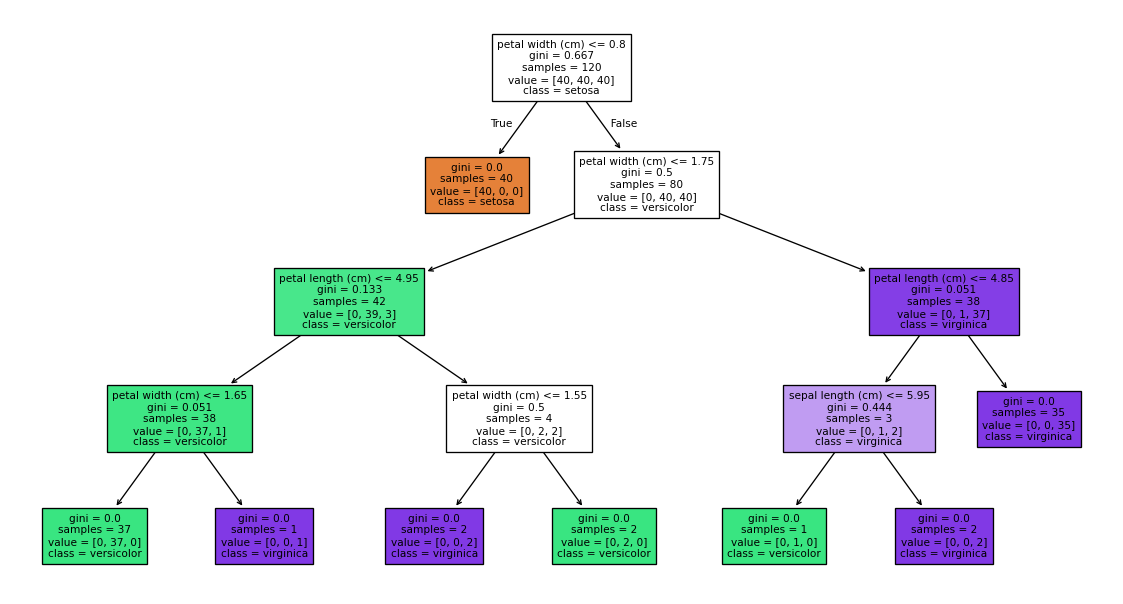

In [10]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
tree=DecisionTreeClassifier(random_state=0).fit(X_train,y_train)
fig,ax=plt.subplots(figsize=(15,8));plot_tree(tree,feature_names=iris.feature_names,class_names=iris.target_names,filled=True,ax=ax,fontsize=8);plt.show()
print('Profondeur et feuilles :',tree.get_depth(),tree.get_n_leaves())

**Réponse.** À chaque nœud, on suit à gauche si la condition `variable ≤ seuil` est vraie, à droite sinon. `samples`, `value` et `class` décrivent le nombre d’exemples, les effectifs par classe et la classe majoritaire ; les feuilles donnent la prédiction.

**Q4**. Check the performance of the decision tree on the test set.

In [13]:
from sklearn.metrics import accuracy_score,confusion_matrix
p=tree.predict(X_test)
print('Accuracy arbre complet :',accuracy_score(y_test,p))
print('Matrice de confusion :\n',confusion_matrix(y_test,p))

Accuracy arbre complet : 0.9666666666666667
Matrice de confusion :
 [[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]


**Réponse.** Le score et la matrice ci-dessus évaluent le modèle sur 30 fleurs jamais vues à l’entraînement.

**Q5.** Now train two other decision trees, using only the petal features for the first one, and the sepal features for the other one.

In both cases, display the tree, and the decision regions (with the training set points). Also check their performance on the test set. Comment.

Pétales: test accuracy=0.967, profondeur=4
Sépales: test accuracy=0.600, profondeur=10


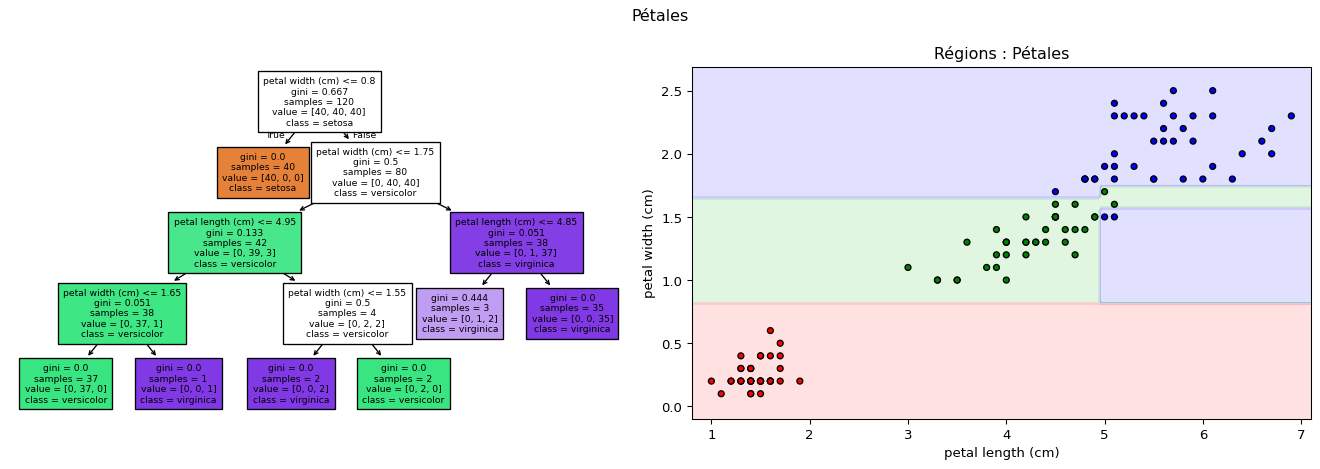

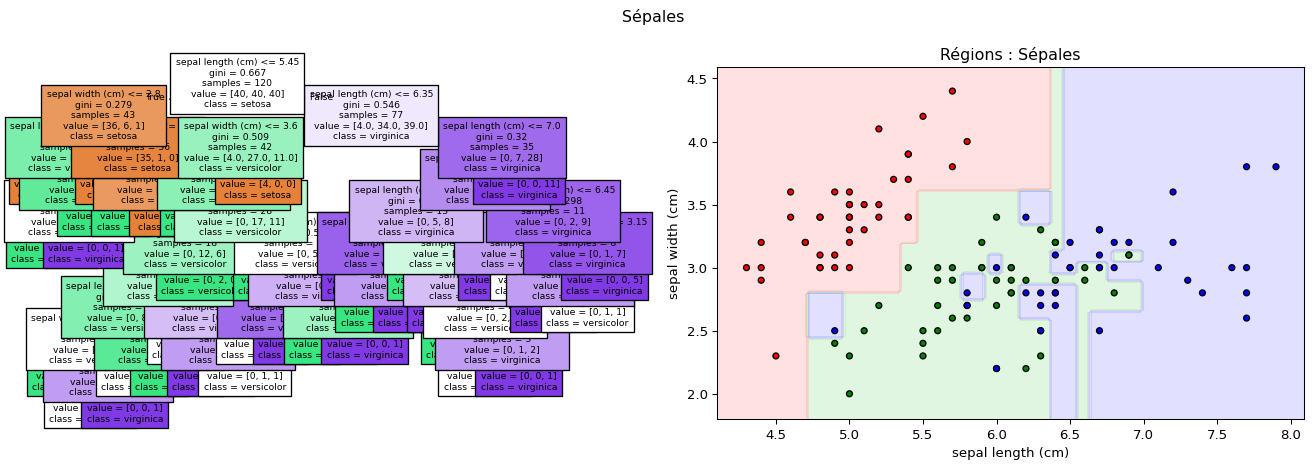

In [16]:
from matplotlib.colors import ListedColormap
subsets={'Pétales':[2,3],'Sépales':[0,1]}
models={}
for title,cols in subsets.items():
    m=DecisionTreeClassifier(random_state=0).fit(X_train[:,cols],y_train)
    models[title]=m
    fig,axes=plt.subplots(1,2,figsize=(14,5))
    plot_tree(m,feature_names=[iris.feature_names[i] for i in cols],class_names=iris.target_names,filled=True,ax=axes[0],fontsize=7)
    xx=X_train[:,cols];step=.03
    x0,x1=np.meshgrid(np.arange(xx[:,0].min()-.2,xx[:,0].max()+.2,step),np.arange(xx[:,1].min()-.2,xx[:,1].max()+.2,step))
    region=m.predict(np.c_[x0.ravel(),x1.ravel()]).reshape(x0.shape)
    axes[1].contourf(x0,x1,region,alpha=.25,cmap=ListedColormap(['#f88','#8d8','#88f']))
    axes[1].scatter(xx[:,0],xx[:,1],c=y_train,cmap=ListedColormap(['red','green','blue']),edgecolor='k',s=20)
    axes[1].set(xlabel=iris.feature_names[cols[0]],ylabel=iris.feature_names[cols[1]],title=f'Régions : {title}')
    fig.suptitle(title);fig.tight_layout();plt.show()
    print(f'{title}: test accuracy={m.score(X_test[:,cols],y_test):.3f}, profondeur={m.get_depth()}')

**Réponse.** Les régions colorées illustrent les coupures successives parallèles aux axes. Les pétales séparent généralement mieux les trois espèces que les sépales ; les scores imprimés permettent de quantifier cette différence sur ce partage.

**Q6.** Check carefully the documentation for `DecisionTreeClassifier`, and explain how a decision tree could be regularized. What method from the lecture is not covered by scikit-learn ?

**Réponse.** Limiter `max_depth`, augmenter `min_samples_split` et `min_samples_leaf`, limiter `max_leaf_nodes`, imposer `min_impurity_decrease` ou utiliser `ccp_alpha` pour un élagage par complexité coût régularise l’arbre. L’élagage par *erreur réduite* sur un ensemble de validation séparé, dans sa forme classique, n’est pas directement implémenté par `DecisionTreeClassifier`.

### Exercice 2 - Random forests

**Q1.** Now train a random forest on the whole dataset, using 200 trees, and setting the maximum depth of each tree to 3. Also add `oob_score = True`.

In [22]:
from sklearn.ensemble import RandomForestClassifier
# Ajustement sur train uniquement : le test reste disponible pour une comparaison équitable.
forest=RandomForestClassifier(n_estimators=200,max_depth=3,oob_score=True,random_state=0,n_jobs=-1).fit(X_train,y_train)
print('Arbres :',len(forest.estimators_),'OOB score :',forest.oob_score_)

Arbres : 200 OOB score : 0.9583333333333334


**Q2.** Extract 5 differents trees from the forest and display them. Comment.

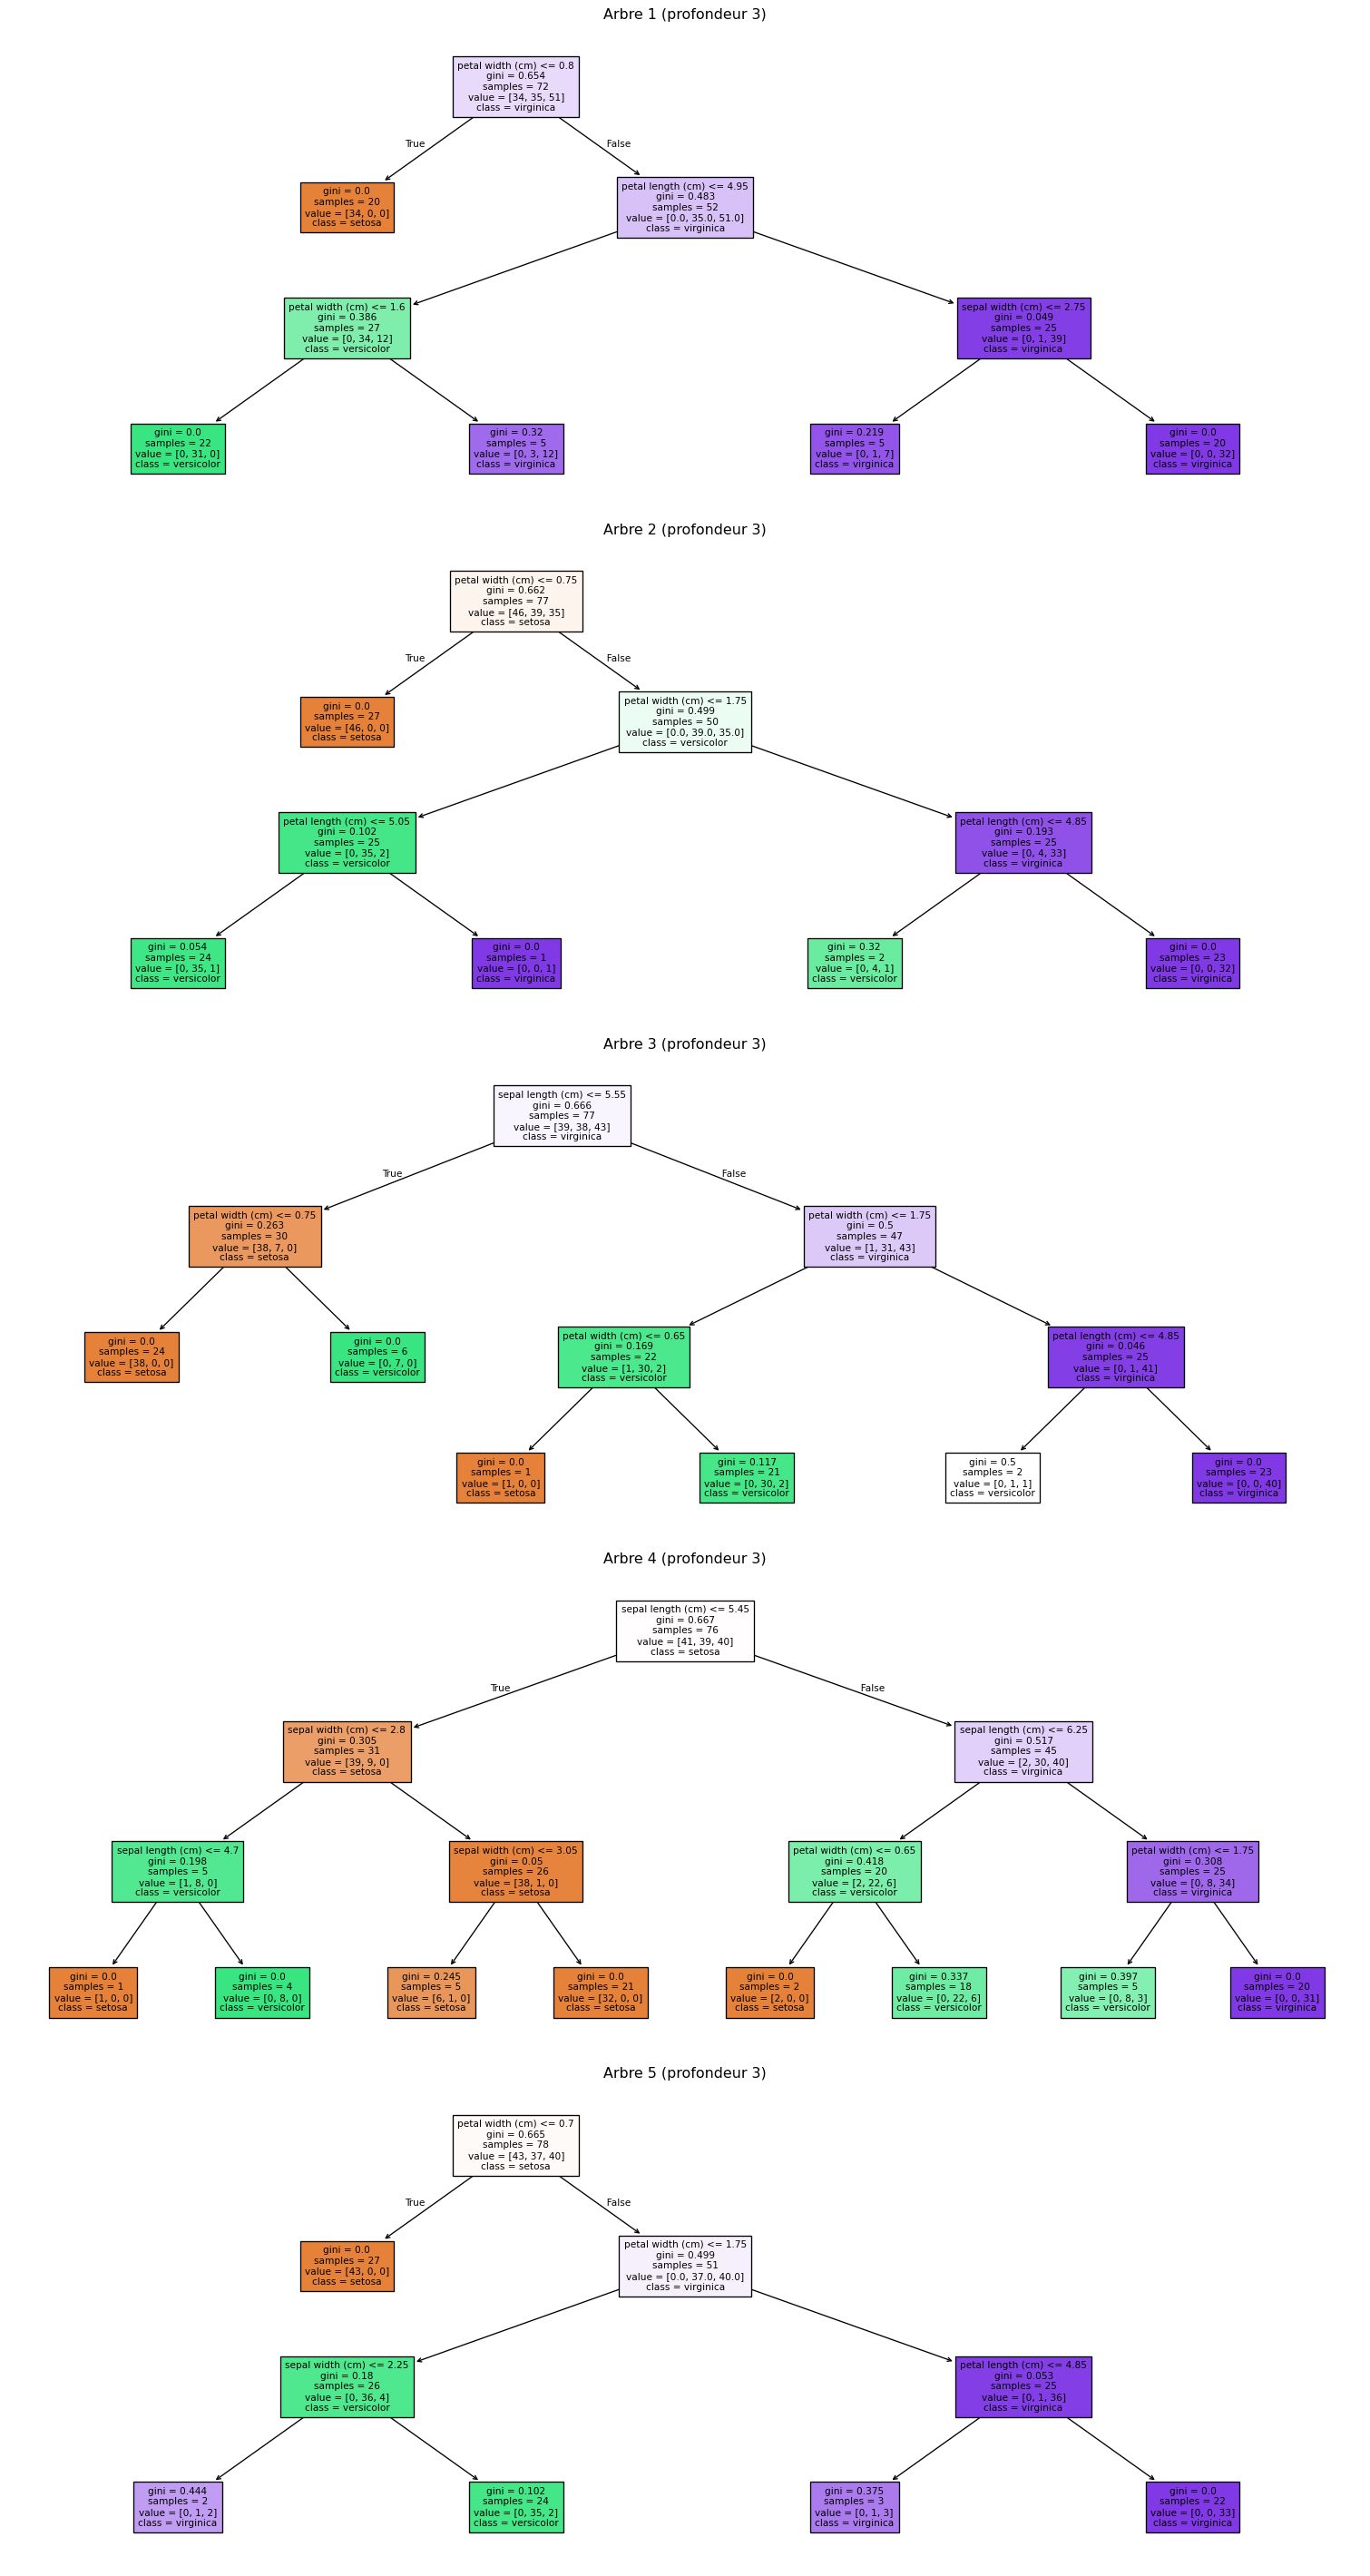

In [24]:
fig,axes=plt.subplots(5,1,figsize=(16,30))
for k,ax in enumerate(axes):
    t=forest.estimators_[k]
    plot_tree(t,feature_names=iris.feature_names,class_names=iris.target_names,filled=True,ax=ax,fontsize=8)
    ax.set_title(f'Arbre {k+1} (profondeur {t.get_depth()})')
fig.tight_layout();plt.show()

**Q3.** Retrieve the feature importance for each feature. Which ones are the most important ? Does this match with what you observed in Q5 of Ex. 1 ?

In [26]:
for name,importance in sorted(zip(iris.feature_names,forest.feature_importances_),key=lambda item:-item[1]):print(f'{name}: {importance:.3f}')

petal width (cm): 0.475
petal length (cm): 0.401
sepal length (cm): 0.107
sepal width (cm): 0.018


**Q4.** Return the out-of-bag (OOB) error and recall how it is computed. Compare the performance of the random forest w.r.t. the decision trees studied in Ex. 1.

In [28]:
print(f'Erreur OOB : {1-forest.oob_score_:.3f}')
print(f'Accuracy test forêt : {forest.score(X_test,y_test):.3f}')
print(f'Accuracy test arbre entier : {tree.score(X_test,y_test):.3f}')
for label,cols in subsets.items():print(f'Accuracy test arbre {label.lower()} : {models[label].score(X_test[:,cols],y_test):.3f}')

Erreur OOB : 0.042
Accuracy test forêt : 0.933
Accuracy test arbre entier : 0.967
Accuracy test arbre pétales : 0.967
Accuracy test arbre sépales : 0.600


**Réponse Q2.** Les cinq arbres n’ont pas exactement les mêmes seuils ni les mêmes variables : chaque arbre voit un échantillon bootstrap et, à chaque division, un sous-ensemble aléatoire des variables.

**Réponse Q3.** Les importances totalisent 1 ; celles des pétales dominent généralement, en accord avec les arbres construits sur les seules variables de pétale. Cette importance de Gini peut favoriser certaines variables.

**Réponse Q4.** Pour chaque arbre, les observations hors de son tirage bootstrap sont évaluées par cet arbre ; chaque observation reçoit un vote des arbres pour lesquels elle est hors sac. `1 - oob_score_` est l’erreur de ces votes. Les scores test ci-dessus sont directement comparables, car tous les modèles ont utilisé le même découpage train/test.